In [1]:
# Código para entrenamiento de CNN
# ============================================================
# 1. CONEXIÓN A GOOGLE DRIVE E IMPORTACIÓN DE LIBRERÍAS
# ============================================================

"""
En esta sección se conecta Google Drive para acceder al dataset
almacenado en la carpeta del proyecto. Además, se importan las
librerías necesarias para:

- cargar imágenes,
- construir datasets de TensorFlow,
- entrenar el modelo,
- calcular métricas,
- visualizar resultados.
"""

from google.colab import drive
drive.mount('/content/drive')

import time
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# DenseNet 121 - Modelo de transfer learning elegido
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras import layers, models

Mounted at /content/drive


In [2]:
# ============================================================
# 2. DEFINICIÓN DE RUTA Y PARÁMETROS GENERALES
# ============================================================

"""
Para este avance se trabajará únicamente con la carpeta train,
debido a que contiene la mayor cantidad de imágenes disponibles, posee
1341 imágenes para clase NORMAL y 3875 imágenes para PNEUMONÍA

A partir de esta carpeta se realizará una nueva división interna:
- entrenamiento
- validación

La división será estratificada para conservar la proporción entre
las clases NORMAL y PNEUMONIA.
"""

BASE = Path('/content/drive/MyDrive/proyecto_patrones_MIV/XRAY')

TRAIN_ORIGINAL_DIR = BASE / 'train'

IMG_SIZE = (224, 224) # Redimensionamiento de 224 x 224
BATCH_SIZE = 32 # Batch predeterminado
SEED = 42 # Semilla que controla la aleatoriedad

print("Ruta train existe:", TRAIN_ORIGINAL_DIR.exists())

# Para ver si existe GPU
tf.config.list_physical_devices('GPU')

Ruta train existe: True


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
# ============================================================
# 3. VERIFICACIÓN DE IMÁGENES EN TRAIN
# ============================================================

"""
Se verifica la cantidad de imágenes disponibles en la carpeta train
para cada clase. Esta información permite identificar el tamaño real
del conjunto de trabajo y evaluar si existe desbalance entre clases.
"""

CLASES = ['NORMAL', 'PNEUMONIA']

image_paths = []
labels = []

for idx, clase in enumerate(CLASES):
    carpeta = TRAIN_ORIGINAL_DIR / clase
    archivos = list(carpeta.glob('*'))

    print(f"{clase}: {len(archivos)} imágenes")

    for archivo in archivos:
        image_paths.append(str(archivo))
        labels.append(idx)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("\nTotal de imágenes usadas:", len(image_paths))
print("0 = NORMAL")
print("1 = PNEUMONIA")
print("Ruta = image_paths shape:", image_paths.shape)
print("Etiquetas = labels shape:", labels.shape)

NORMAL: 1341 imágenes
PNEUMONIA: 3875 imágenes

Total de imágenes usadas: 5216
0 = NORMAL
1 = PNEUMONIA
Ruta = image_paths shape: (5216,)
Etiquetas = labels shape: (5216,)


In [4]:
# ============================================================
# 4. DIVISIÓN ESTRATIFICADA TRAIN / VALIDATION
# ============================================================

"""
A partir de la carpeta train original se crea una división interna
para entrenamiento y validación.

Se utiliza una división estratificada 80/20:
- 80% para entrenamiento
- 20% para validación

Esto permite validar el modelo con una cantidad suficiente de imágenes
y mantener una proporción similar de clases en ambos subconjuntos.
"""

from sklearn.model_selection import train_test_split
from collections import Counter

# Asegurar formato de arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.20, # Validación de 20%
    stratify=labels, # División estratificada
    random_state=SEED
)

print("Entrenamiento:", len(X_train), Counter(y_train))
print("Validación:", len(X_val), Counter(y_val))
print("\nEl conjunto test se mantiene reservado para la evaluación final.")

Entrenamiento: 4172 Counter({np.int64(1): 3099, np.int64(0): 1073})
Validación: 1044 Counter({np.int64(1): 776, np.int64(0): 268})

El conjunto test se mantiene reservado para la evaluación final.


In [5]:
# ============================================================
# 5. MANEJO DEL DESBALANCE DE CLASES
# ============================================================

"""
Se calculan pesos de clase para compensar el desbalance entre NORMAL y PNEUMONIA.
La clase con menor cantidad de imágenes recibe mayor peso durante el entrenamiento, así se puede evitar
que el modelo favorezca a la clase mayoritaria.
"""

from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced', # Balanceado, considerando la proporción de las clases
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: float(class_weights_array[0]),  # NORMAL
    1: float(class_weights_array[1])   # PNEUMONIA
}

print("Pesos de clase:")
print("NORMAL:", class_weights[0])
print("PNEUMONIA:", class_weights[1])

Pesos de clase:
NORMAL: 1.9440820130475303
PNEUMONIA: 0.6731203614069055


In [6]:
# ============================================================
# 6. CREACIÓN DE DATASETS CON TENSORFLOW
# ============================================================

"""
En esta sección se convierten las rutas de imágenes y sus etiquetas
en datasets de TensorFlow.

Esto permitirá alimentar el modelo CNN en lotes de imágenes durante
el entrenamiento y la validación.
"""

AUTOTUNE = tf.data.AUTOTUNE # Uso de mejor cantidad de datos

def cargar_imagen(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3) # En este caso, para DenseNet es necesario usar 3 canales
    img = tf.image.resize(img, IMG_SIZE) # Resize de 224 x 224
    img = tf.cast(img, tf.float32)
    label = tf.cast(label, tf.float32)
    return img, label



train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

# Procesamiento de cada imagen, pasa a tener imágenes procesadas
train_ds = train_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)

# Mezcla de dataset en entrenamiento
train_ds = train_ds.shuffle(
    buffer_size=len(X_train),
    seed=SEED
)

# Creación de los batches en train
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
# En validación
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Dataset de entrenamiento creado correctamente")
print("Dataset de validación creado correctamente")

Dataset de entrenamiento creado correctamente
Dataset de validación creado correctamente


In [7]:
# ============================================================
# 7. DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03), # +-10.8 grados
    tf.keras.layers.RandomZoom(0.10), # Zoom aleatorio de un 10%
    tf.keras.layers.RandomTranslation(0.05, 0.05), # Movimiento aleatorio de un 5%
], name="data_augmentation")

print("Data augmentation definido correctamente")

Data augmentation definido correctamente


In [8]:
# ============================================================
# 8. DenseNet con ImageNet
# ============================================================

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

base_model = DenseNet121(
    weights="imagenet", # Pesos preentrenados de ImageNet
    include_top=False, # Quito la cabeza original de ImageNet para la clasificación propia
    input_shape=(224, 224, 3) # Input ya elegido
)

base_model.trainable = False # Congelo la base convolucional al inicio
# Es decir, durante el entrenamiento no cambio los pesos extraídos de ImageNet

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs) # DataAugmentation
x = layers.Lambda(preprocess_input)(x) # Normalización para DenseNet
x = base_model(x, training=False) # Aquí las imágenes entran a DenseNet
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
# Salida final del modelo, sigmoid usa un valor entre 0 y 1
outputs = layers.Dense(1, activation="sigmoid")(x)

modelo_densenet121 = models.Model(inputs, outputs, name="DenseNet121_transfer")


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# ============================================================
# 9. CARPETA DE RESULTADOS
# ============================================================

RESULTS_DIR = BASE / "resultados_densenet121_batch32_cambiofinetuning"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Resultados se guardarán en:", RESULTS_DIR)

Resultados se guardarán en: /content/drive/MyDrive/proyecto_patrones_MIV/XRAY/resultados_densenet121_batch32_cambiofinetuning


In [10]:
# ============================================================
# 10. COMPILACIÓN DEL MODELO - ETAPA 1: BASE CONGELADA
# ============================================================

"""
En esta primera etapa se entrena únicamente la cabeza clasificadora
agregada sobre DenseNet121.
"""

# Reglas de entrenamiento
modelo_densenet121.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks = [
    # Detiene el entrenamiento si no mejora
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5, # Límite: 5 épocas
        mode="max",
        restore_best_weights=True # Se usan los pesos de la mejor época
    ),

    # Guardado del mejor modelo durante el entrenamiento
    tf.keras.callbacks.ModelCheckpoint(
        str(RESULTS_DIR / "modelo_densenet121_frozen.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True
    ),

    # Reduce el Learning Rate en caso de estancamientoYa,
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.2,
        patience=2,
        mode="max",
        min_lr=1e-6
    )
]

In [11]:
# ============================================================
# 11. ENTRENAMIENTO PRELIMINAR DEL MODELO BASELINE
# ============================================================

inicio_frozen = time.time()

# Entrenamiento
history_frozen = modelo_densenet121.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)

fin_frozen = time.time()

tiempo_frozen = fin_frozen - inicio_frozen

print(f"Tiempo de entrenamiento preliminar: {tiempo_frozen/60:.2f} minutos")

Epoch 1/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 594s 804ms/step - accuracy: 0.7965 - auc: 0.9389 - loss: 0.3462 - precision: 0.9751 - recall: 0.7451 - val_accuracy: 0.8851 - val_auc: 0.9877 - val_loss: 0.2895 - val_precision: 0.9970 - val_recall: 0.8479 - learning_rate: 3.0000e-04
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 248ms/step - accuracy: 0.9243 - auc: 0.9780 - loss: 0.1887 - precision: 0.9783 - recall: 0.9184 - val_accuracy: 0.9339 - val_auc: 0.9909 - val_loss: 0.1836 - val_precision: 0.9958 - val_recall: 0.9149 - learning_rate: 3.0000e-04
Epoch 3/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 66s 239ms/step - accuracy: 0.9406 - auc: 0.9863 - loss: 0.1494 - precision: 0.9808 - recall: 0.9384 - val_accuracy: 0.9464 - val_auc: 0.9928 - val_loss: 0.1383 - val_precision: 0.9932 - val_recall: 0.9343 - learning_rate: 3.0000e-04
Epoch 4/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 241ms/step - accuracy: 0.9408 - auc: 0.9877 - loss: 0.1395 - precision: 0.9834 - recall: 0.9361 - val_accuracy: 0.9425 - val_auc: 0.9936

In [12]:
# ============================================================
# 12. FINE-TUNING DE DENSENET121
# ============================================================

"""
Se descongelan únicamente las capas finales del último bloque denso
de DenseNet121, mientras que las capas iniciales permanecen congeladas.

Esto permite adaptar mejor el modelo al dominio de radiografías
de tórax sin incrementar demasiado el costo computacional.
"""

# Descongelar toda la base primero
base_model.trainable = True

# Volver a congelar todas las capas excepto las del último bloque denso
for layer in base_model.layers:
    if not layer.name.startswith("conv5_block"):
        layer.trainable = False

# Número de capas entrenables
trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
total_count = len(base_model.layers)

print("Capas entrenables en base_model:", trainable_count)
print("Capas totales en base_model:", total_count)

# Recompilación con L.R. más bajo, para no modificar mucho los pesos
modelo_densenet121.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Nuevos callbacks para fine-tuning
callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=4,
        mode="max",
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        str(RESULTS_DIR / "modelo_densenet121_finetuned.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.2,
        patience=2,
        mode="max",
        min_lr=1e-7
    )
]

inicio_finetune = time.time()

# Entrenamiento de fine-tuning con el nuevo modelo
history_finetune = modelo_densenet121.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

fin_finetune = time.time()
tiempo_finetune = fin_finetune - inicio_finetune
print(f"Tiempo de entrenamiento fine-tuning: {tiempo_finetune/60:.2f} minutos")

Capas entrenables en base_model: 112
Capas totales en base_model: 427
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 315ms/step - accuracy: 0.9413 - auc: 0.9843 - loss: 0.1592 - precision: 0.9747 - recall: 0.9455 - val_accuracy: 0.9674 - val_auc: 0.9962 - val_loss: 0.0894 - val_precision: 0.9973 - val_recall: 0.9588 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 83s 355ms/step - accuracy: 0.9442 - auc: 0.9898 - loss: 0.1269 - precision: 0.9848 - recall: 0.9393 - val_accuracy: 0.9598 - val_auc: 0.9963 - val_loss: 0.1111 - val_precision: 1.0000 - val_recall: 0.9459 - learning_rate: 1.0000e-05
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 83s 356ms/step - accuracy: 0.9487 - auc: 0.9884 - loss: 0.1347 - precision: 0.9829 - recall: 0.9474 - val_accuracy: 0.9579 - val_auc: 0.9964 - val_loss: 0.1132 - val_precision: 1.0000 - val_recall: 0.9433 - learning_rate: 1.0000e-05
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 339ms/step - accuracy: 0.9523 - auc: 0.9919 - loss: 0.1105 - preci

In [13]:
# Guardado del modelo final
modelo_densenet121.save(RESULTS_DIR / "modelo_densenet121_final_batch_32_f_cambiado.keras")

# Tiempo total de la computación
tiempo_total = tiempo_frozen + tiempo_finetune
print(f"Tiempo total de entrenamiento: {tiempo_total/60:.2f} minutos")

Tiempo total de entrenamiento: 44.55 minutos


In [14]:
# ============================================================
# REPORTE DE MEJOR ÉPOCA SEGÚN EARLY STOPPING
# ============================================================

def reportar_mejor_epoca(history, nombre_etapa, offset=0):
    val_auc = history.history["val_auc"]
    val_loss = history.history["val_loss"]

    mejor_idx_auc = np.argmax(val_auc)
    mejor_epoca_auc = mejor_idx_auc + 1 + offset

    mejor_idx_loss = np.argmin(val_loss)
    mejor_epoca_loss = mejor_idx_loss + 1 + offset

    print(f"\nEtapa: {nombre_etapa}")
    print(f"Mejor época según val_auc: {mejor_epoca_auc}")
    print(f"Mejor val_auc: {val_auc[mejor_idx_auc]:.4f}")
    print(f"val_loss en esa época: {val_loss[mejor_idx_auc]:.4f}")

    print(f"Mejor época según val_loss: {mejor_epoca_loss}")
    print(f"Mejor val_loss: {val_loss[mejor_idx_loss]:.4f}")
    print(f"val_auc en esa época: {val_auc[mejor_idx_loss]:.4f}")

    if mejor_epoca_auc == mejor_epoca_loss:
        print("La mejor época por val_auc coincide con la mejor época por val_loss.")
    else:
        print("La mejor época por val_auc NO coincide con la mejor época por val_loss.")


# Etapa 1: DenseNet congelada
reportar_mejor_epoca(
    history_frozen,
    nombre_etapa="Base congelada",
    offset=0
)

# Etapa 2: Fine-tuning
offset_finetune = len(history_frozen.history["val_auc"])

reportar_mejor_epoca(
    history_finetune,
    nombre_etapa="Fine-tuning",
    offset=offset_finetune
)


Etapa: Base congelada
Mejor época según val_auc: 18
Mejor val_auc: 0.9969
val_loss en esa época: 0.1138
Mejor época según val_loss: 21
Mejor val_loss: 0.1110
val_auc en esa época: 0.9968
La mejor época por val_auc NO coincide con la mejor época por val_loss.

Etapa: Fine-tuning
Mejor época según val_auc: 26
Mejor val_auc: 0.9964
val_loss en esa época: 0.1132
Mejor época según val_loss: 24
Mejor val_loss: 0.0894
val_auc en esa época: 0.9962
La mejor época por val_auc NO coincide con la mejor época por val_loss.


In [15]:
# ============================================================
# MEJOR ÉPOCA GLOBAL ENTRE BASE CONGELADA + FINE-TUNING
# ============================================================

val_auc_total = history_frozen.history["val_auc"] + history_finetune.history["val_auc"]
val_loss_total = history_frozen.history["val_loss"] + history_finetune.history["val_loss"]

mejor_idx_global_auc = np.argmax(val_auc_total)
mejor_epoca_global_auc = mejor_idx_global_auc + 1

mejor_idx_global_loss = np.argmin(val_loss_total)
mejor_epoca_global_loss = mejor_idx_global_loss + 1

print("\nMejor modelo global según val_auc:")
print("Época:", mejor_epoca_global_auc)
print("val_auc:", val_auc_total[mejor_idx_global_auc])
print("val_loss en esa época:", val_loss_total[mejor_idx_global_auc])

print("\nMejor época global según val_loss:")
print("Época:", mejor_epoca_global_loss)
print("val_loss:", val_loss_total[mejor_idx_global_loss])
print("val_auc en esa época:", val_auc_total[mejor_idx_global_loss])


Mejor modelo global según val_auc:
Época: 18
val_auc: 0.9969369769096375
val_loss en esa época: 0.1137673556804657

Mejor época global según val_loss:
Época: 24
val_loss: 0.08944293856620789
val_auc en esa época: 0.996167778968811


In [16]:
# ============================================================
# 13. EVALUACIÓN DEL MODELO EN VALIDACIÓN
# ============================================================

val_loss, val_acc, val_auc, val_precision, val_recall = modelo_densenet121.evaluate(val_ds)

print("Resultados en validación:")
print("Loss:", val_loss)
print("Accuracy:", val_acc)
print("AUC:", val_auc)
print("Precision:", val_precision)
print("Recall/Sensibilidad:", val_recall)

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 310ms/step - accuracy: 0.9579 - auc: 0.9964 - loss: 0.1132 - precision: 1.0000 - recall: 0.9433
Resultados en validación:
Loss: 0.11322134733200073
Accuracy: 0.9578543901443481
AUC: 0.9963551759719849
Precision: 1.0
Recall/Sensibilidad: 0.9432989954948425


In [31]:
# ============================================================
# 14. MATRIZ DE CONFUSIÓN Y MÉTRICAS
# ============================================================

y_true = []
y_prob = []

for images, labels_batch in val_ds:
    probs = modelo_densenet121.predict(images, verbose=0)
    y_prob.extend(probs.ravel())
    y_true.extend(labels_batch.numpy())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)  # sensibilidad para PNEUMONIA
f1 = f1_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_prob)

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Matriz de confusión:")
print(cm)

print("\nMétricas de validación:")
print("Accuracy:", accuracy)
print("Sensibilidad / Recall PNEUMONIA:", sensitivity)
print("Especificidad / Recall NORMAL:", specificity)
print("Precision:", precision)
print("F1-score:", f1)
print("AUC-ROC:", auc_score)

print("\nReporte de clasificación:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

Matriz de confusión:
[[265   3]
 [ 24 752]]

Métricas de validación:
Accuracy: 0.9741379310344828
Sensibilidad / Recall PNEUMONIA: 0.9690721649484536
Especificidad / Recall NORMAL: 0.9888059701492538
Precision: 0.9960264900662251
F1-score: 0.9823644676681907
AUC-ROC: 0.9964898445914756

Reporte de clasificación:
              precision    recall  f1-score   support

      NORMAL       0.92      0.99      0.95       268
   PNEUMONIA       1.00      0.97      0.98       776

    accuracy                           0.97      1044
   macro avg       0.96      0.98      0.97      1044
weighted avg       0.98      0.97      0.97      1044



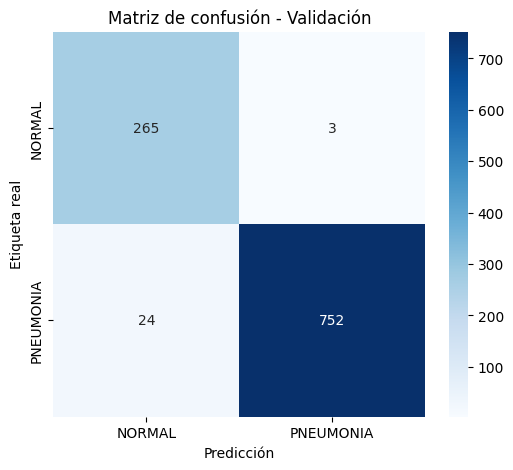

In [26]:
# ============================================================
# 15. VISUALIZACIÓN DE MATRIZ DE CONFUSIÓN
# ============================================================

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - Validación")
plt.savefig(RESULTS_DIR / "matriz_confusion_validacion.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# ============================================================
# TABLA DE FALSOS NEGATIVOS Y FALSOS POSITIVOS
# ============================================================

errores_df = pd.DataFrame({
    "path": X_val,
    "y_true": y_true,
    "y_prob_pneumonia": y_prob,
    "y_pred": y_pred
})

errores_df["clase_real"] = errores_df["y_true"].map({
    0: "NORMAL",
    1: "PNEUMONIA"
})

errores_df["clase_predicha"] = errores_df["y_pred"].map({
    0: "NORMAL",
    1: "PNEUMONIA"
})

falsos_negativos = errores_df[
    (errores_df["y_true"] == 1) & (errores_df["y_pred"] == 0)
]

falsos_positivos = errores_df[
    (errores_df["y_true"] == 0) & (errores_df["y_pred"] == 1)
]

print("Cantidad de falsos negativos:", len(falsos_negativos))
display(falsos_negativos[["path", "clase_real", "clase_predicha", "y_prob_pneumonia"]])

print("Cantidad de falsos positivos:", len(falsos_positivos))
display(falsos_positivos[["path", "clase_real", "clase_predicha", "y_prob_pneumonia"]])

Cantidad de falsos negativos: 44


,path,clase_real,clase_predicha,y_prob_pneumonia
9,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.001495
23,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.030560
85,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.307043
86,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.431280
91,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.372215
131,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.027747
138,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.445614
146,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.085409
284,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.113086
301,/content/drive/MyDrive/proyecto_patrones_MIV/X...,PNEUMONIA,NORMAL,0.061587


Cantidad de falsos positivos: 0


,path,clase_real,clase_predicha,y_prob_pneumonia


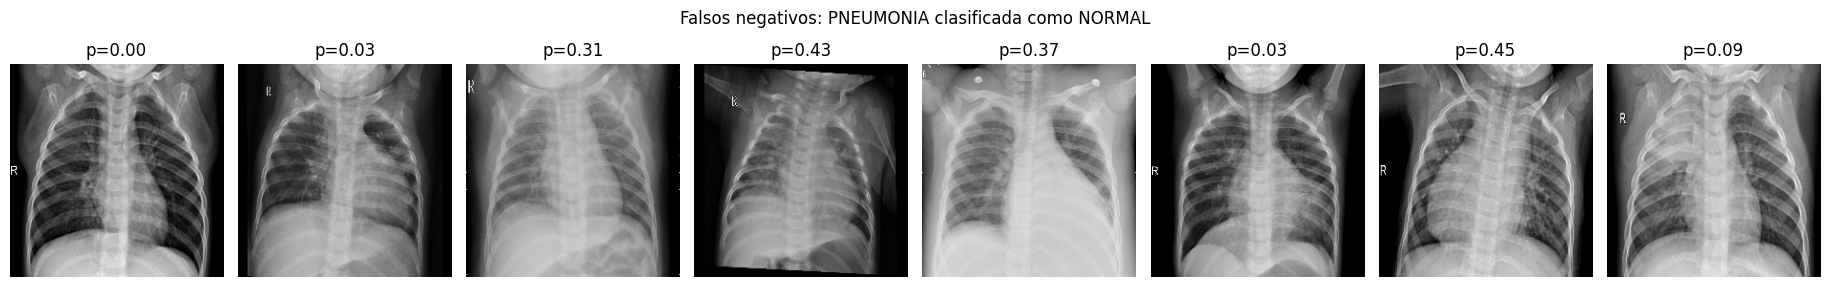

No se encontraron errores tipo FP con threshold=0.5.


In [20]:
# ============================================================
# 16. VISUALIZACIÓN DE FALSOS NEGATIVOS Y FALSOS POSITIVOS
# ============================================================

def mostrar_errores_imagenes(paths, y_true, y_prob, threshold=0.5, error_type="FN", max_images=8):
    """
    Visualiza imágenes mal clasificadas:
    FN: PNEUMONIA real clasificada como NORMAL
    FP: NORMAL real clasificada como PNEUMONIA
    """

    y_pred = (y_prob >= threshold).astype(int)

    if error_type == "FN":
        idxs = np.where((y_true == 1) & (y_pred == 0))[0]
        titulo = "Falsos negativos: PNEUMONIA clasificada como NORMAL"

    elif error_type == "FP":
        idxs = np.where((y_true == 0) & (y_pred == 1))[0]
        titulo = "Falsos positivos: NORMAL clasificado como PNEUMONIA"

    else:
        raise ValueError("error_type debe ser 'FN' o 'FP'")

    if len(idxs) == 0:
        print(f"No se encontraron errores tipo {error_type} con threshold={threshold}.")
        return

    chosen = idxs[:max_images]

    fig, axes = plt.subplots(1, len(chosen), figsize=(2.3 * len(chosen), 3))

    if len(chosen) == 1:
        axes = [axes]

    for ax, idx in zip(axes, chosen):
        img = tf.io.read_file(str(paths[idx]))
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = img.numpy().astype("uint8")

        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(f"p={y_prob[idx]:.2f}")

    plt.suptitle(titulo)
    plt.tight_layout()

    nombre_archivo = f"{error_type}_threshold_{threshold}.png"
    plt.savefig(RESULTS_DIR / nombre_archivo, dpi=300, bbox_inches="tight")

    plt.show()

mostrar_errores_imagenes(
    X_val,
    y_true,
    y_prob,
    threshold=0.5,
    error_type="FN",
    max_images=8
)

mostrar_errores_imagenes(
    X_val,
    y_true,
    y_prob,
    threshold=0.5,
    error_type="FP",
    max_images=8
)

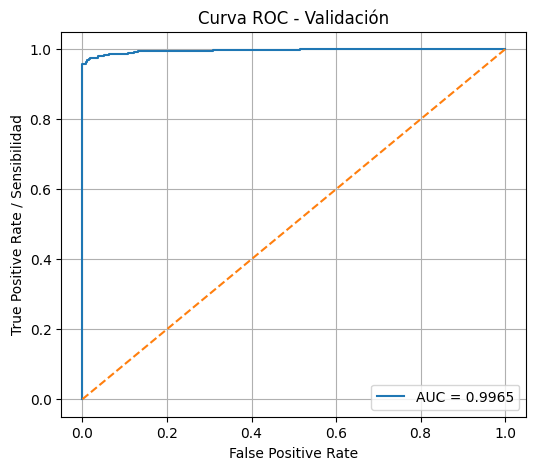

In [21]:
# ============================================================
# 17. CURVA ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensibilidad")
plt.title("Curva ROC - Validación")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "curva_roc_validacion.png", dpi=300, bbox_inches="tight")
plt.show()

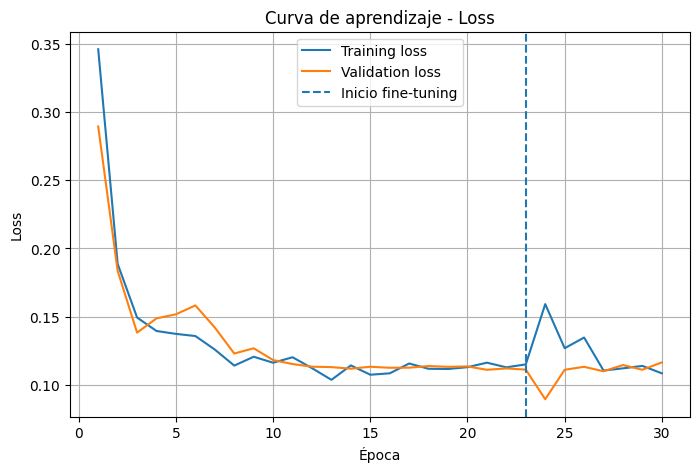

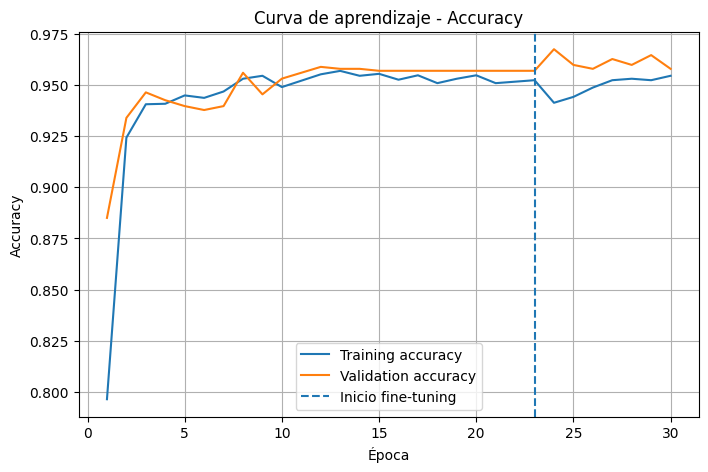

In [22]:
# ============================================================
# 18. CURVAS DE APRENDIZAJE: LOSS Y ACCURACY
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Unir historial de etapa congelada + fine-tuning
loss = history_frozen.history["loss"] + history_finetune.history["loss"]
val_loss = history_frozen.history["val_loss"] + history_finetune.history["val_loss"]

accuracy = history_frozen.history["accuracy"] + history_finetune.history["accuracy"]
val_accuracy = history_frozen.history["val_accuracy"] + history_finetune.history["val_accuracy"]

epochs = range(1, len(loss) + 1)

# ----------------------------
# Curva de Loss
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.axvline(x=len(history_frozen.history["loss"]), linestyle="--", label="Inicio fine-tuning")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de aprendizaje - Loss")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "curva_loss.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Curva de Accuracy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.axvline(x=len(history_frozen.history["accuracy"]), linestyle="--", label="Inicio fine-tuning")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje - Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "curva_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()